In [24]:
import pandas as pd
import sys # sys is imported so we can modify python's module search path
import os # for operating system related functionalities

sys.path.append('../') # allows python to find and import files from folder

# import the reusable data loader function from src/data_loader.py
from src.data_loader import load_cement_data

In [25]:
# load cement dataset into pandas DataFrame
df = load_cement_data()

In [26]:
# display summary of the DataFrame structure.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      32880 non-null  datetime64[ns]
 1   site_id                   32880 non-null  object        
 2   region                    32880 non-null  object        
 3   behavior                  32880 non-null  object        
 4   cement_type               32880 non-null  object        
 5   planned_pour_tonnes       32880 non-null  float64       
 6   consumed_tonnes           32880 non-null  float64       
 7   opening_inventory_tonnes  32880 non-null  float64       
 8   deliveries_tonnes         32880 non-null  float64       
 9   closing_inventory_tonnes  32880 non-null  float64       
 10  rain_mm                   32880 non-null  float64       
 11  avg_temp_c                32880 non-null  float64       
 12  silo_capacity     

In [27]:
# check whether the inventory balance eequation is correct for each row.
df['inventory_check'] = (
  df['opening_inventory_tonnes']
  + df['deliveries_tonnes'] 
  - df['consumed_tonnes']
).round(2) == df['closing_inventory_tonnes'].round(2)

df['inventory_check'].head() # True means the row passes the inventory check balance

0    True
1    True
2    True
3    True
4    True
Name: inventory_check, dtype: bool

In [28]:
# calculate the % of rows where the inventory balance check passed
df['inventory_check'].mean()

np.float64(0.999787104622871)

In [29]:
# create a flag that identifies days when a site ended with zero cement inventory
df['end_of_day_stockout'] = df['closing_inventory_tonnes'] == 0

In [30]:
# Create a flag for pour readiness failure, to check whether planned pour quantity is greater than the cement available for the day
df['pour_readiness_failure'] = df['planned_pour_tonnes'] > (
  df['opening_inventory_tonnes'] + df['deliveries_tonnes']
)


In [31]:
# create a flag for overcapacity, to check whether the closing inventory is greater than the site's silo capacity
df['overcapacity'] = df['closing_inventory_tonnes'] > df['silo_capacity']

In [32]:
# create a flag for waste risk, where closing inventory is above 85% of silo capacity, and planned pour is very low
df['waste_risk'] = (
  (df['closing_inventory_tonnes'] > 0.85 * df['silo_capacity']) 
  & (df['planned_pour_tonnes'] < 0.5)
)

In [33]:
# create a flag for idle days, where there are no planned pour, and no cement deliveries
df['idle'] = (
  (df['planned_pour_tonnes'] == 0) 
  & (df['deliveries_tonnes'] == 0)
)

In [34]:
# create a flag for pour disruption, days when there are planned pour, but no cement was actually consumed
df['pour_disrupt'] = (
  (df['planned_pour_tonnes'] > 0) 
  & (df['consumed_tonnes'] == 0)
)

In [35]:
# create a flag for low inventory, where opening inventory is below 20% of silo capacity
df['low_inventory'] = (
  df['opening_inventory_tonnes'] < 0.20 * df['silo_capacity']
)

In [36]:
# create a flag for delivery days, when the site receives more than o tonnes of cement
df['delivery_day'] = df['deliveries_tonnes'] > 0

In [37]:
# create a flag for reactive ordering, where inventory is below 20% of silo capacity and cement delivery was received same day.
df['reactive_ordering'] = (
  (df['opening_inventory_tonnes'] < 0.20 * df['silo_capacity']) 
  & (df['deliveries_tonnes'] > 0)
)

In [38]:
# key performance index summary.
# group dataset by site id so that each row represent one site output
kpi_summary = df.groupby('site_id').agg(
  total_days = ('date', 'count'), # count how many days each site has.
  total_consumed_tonnes = ('consumed_tonnes', 'sum'), # calculate total cement consumed for each site
  avg_daily_consumed = ('consumed_tonnes', 'mean'), # calculate avergae daily cement consumption for each site

  end_of_day_stockout_pct = ('end_of_day_stockout', lambda x: round(x.mean() * 100, 2)), # calc % of days where site ended with zero inventory
  pour_readiness_failure_pct = ('pour_readiness_failure', lambda x: round(x.mean() * 100, 2)), # calc % of days where planned pour was greater than available cement
  overcapacity_pct = ('overcapacity', lambda x: round(x.mean() * 100, 2)), # calc % of days where closing inventory exceeded silo capacity
  waste_risk_pct = ('waste_risk', lambda x: round(x.mean() * 100, 2)), # calc % of days where the site had high stock but very low planned demand
  idle_pct = ('idle', lambda x: round(x.mean() * 100, 2)), # calc % of days with no planned pour and no deliveries
  pour_disrupt_pct = ('pour_disrupt', lambda x: round(x.mean() * 100, 2)), # calc % of days where a pour was planned but no cement was consumed
  low_inventory_pct = ('low_inventory', lambda x: round(x.mean() * 100, 2)), # calc % of days where opening inventory was below 20% of silo capacity
  delivery_freq_pct = ('delivery_day', lambda x: round(x.mean() * 100, 2)), # calc how often each site received deliveries
  reactive_ordering_pct = ('reactive_ordering', lambda x: round(x.mean() * 100, 2)), # calc how often deliveries occured when opening inventory was already low

  silo_capacity = ('silo_capacity', 'first'), # keep site's silo capacity in summary
  region = ('region', 'first')
).reset_index() # convert site id from index back into a normal column

In [39]:
kpi_summary.head()

,site_id,total_days,total_consumed_tonnes,avg_daily_consumed,end_of_day_stockout_pct,pour_readiness_failure_pct,overcapacity_pct,waste_risk_pct,idle_pct,pour_disrupt_pct,low_inventory_pct,delivery_freq_pct,reactive_ordering_pct,silo_capacity,region
0,SITE_001,1096,33056.40,30.160949,46.53,55.75,0.00,0.00,0.0,4.84,98.91,100.0,98.91,448,North
1,SITE_002,1096,12900.44,11.770474,0.00,0.00,98.81,3.56,0.0,0.00,0.46,100.0,0.46,288,South
2,SITE_003,1096,32520.09,29.671615,45.35,54.38,0.00,0.00,0.0,5.75,93.16,100.0,93.16,314,East
3,SITE_004,1096,12618.50,11.513230,0.00,0.00,98.08,4.93,0.0,0.00,0.27,100.0,0.27,472,South
4,SITE_005,1096,32935.68,30.050803,47.08,56.93,0.00,0.00,0.0,4.38,91.79,100.0,91.79,230,South


In [40]:
kpi_summary.to_csv("../data/processed/MIG_kpi_summary.csv", index=False)

In [41]:
# Create a composite problem score for each site
kpi_summary["problem_score"] = (
    (kpi_summary["pour_readiness_failure_pct"] > 0).astype(int) +
    (kpi_summary["end_of_day_stockout_pct"] > 0).astype(int) +
    (kpi_summary["waste_risk_pct"] > 0).astype(int) +
    (kpi_summary["reactive_ordering_pct"] > 20).astype(int) +
    (kpi_summary["overcapacity_pct"] > 0).astype(int) +
    (kpi_summary["low_inventory_pct"] > 20).astype(int) +
    (kpi_summary["pour_disrupt_pct"] > 0).astype(int)
)

problem_sites = kpi_summary[kpi_summary['problem_score'] >= 2]
problem_sites = problem_sites.sort_values(
  "problem_score",
  ascending=False
)

problem_sites.head()

,site_id,total_days,total_consumed_tonnes,avg_daily_consumed,end_of_day_stockout_pct,pour_readiness_failure_pct,overcapacity_pct,waste_risk_pct,idle_pct,pour_disrupt_pct,low_inventory_pct,delivery_freq_pct,reactive_ordering_pct,silo_capacity,region,problem_score
13,SITE_014,1096,29338.97,26.769133,6.11,7.30,32.21,10.22,2.01,3.92,24.54,90.33,22.17,230,West,7
15,SITE_016,1096,29339.46,26.769580,10.04,11.95,15.33,3.28,2.83,3.65,55.38,88.32,49.82,487,East,7
25,SITE_026,1096,29875.39,27.258568,7.76,8.49,6.66,3.01,2.37,4.20,35.77,89.60,32.21,369,South,7
27,SITE_028,1096,28947.34,26.411807,8.21,9.67,16.79,6.02,2.74,3.01,32.57,89.51,28.92,395,East,7
5,SITE_006,1096,28601.16,26.095949,13.41,16.15,0.00,0.09,2.55,3.47,60.04,88.41,53.47,443,East,6


In [42]:
from src.report_builder import build_kpi_report

build_kpi_report(
    kpi_summary=kpi_summary,
    problem_sites=problem_sites,
    output_path="../reports/kpi_analysis.html"
)

kpi_analysis.html created successfully.


In [43]:
# Calculate summary numbers for the report
total_sites = kpi_summary["site_id"].nunique()
problem_site_count = problem_sites["site_id"].nunique()

avg_stockout = round(kpi_summary["end_of_day_stockout_pct"].mean(), 2)
avg_pour_failure = round(kpi_summary["pour_readiness_failure_pct"].mean(), 2)
avg_overcapacity = round(kpi_summary["overcapacity_pct"].mean(), 2)
avg_waste_risk = round(kpi_summary["waste_risk_pct"].mean(), 2)

# Create the HTML report
with open("../reports/kpi_analysis.html", "w", encoding="utf-8") as file:
    file.write("<h1>MIG Cement KPI Analysis Report</h1>")

    file.write("<h2>Business Impact Summary</h2>")
    file.write(f"""
    <p>
    The KPI analysis covers {total_sites} sites. Based on the composite problem score,
    {problem_site_count} sites were identified as problem sites.
    </p>

    <p>
    Across all sites, average end-of-day stockout is {avg_stockout}%,
    average pour readiness failure is {avg_pour_failure}%,
    average overcapacity is {avg_overcapacity}%, and average waste risk is {avg_waste_risk}%.
    </p>
    """)

    file.write("<h2>Problem Site Identification</h2>")
    file.write(problem_sites.to_html(index=False))

    file.write("<h2>Site-Level KPI Scorecard</h2>")
    file.write(kpi_summary.to_html(index=False))

print("kpi_analysis.html created successfully.")

kpi_analysis.html created successfully.


continuation of class

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# top 15 sites that comsumes a lot of cement
top_sites = kpi_summary.sort_values('total_consumed_tonnes', ascending=False).head(15)

In [47]:
top_sites

,site_id,total_days,total_consumed_tonnes,avg_daily_consumed,end_of_day_stockout_pct,pour_readiness_failure_pct,overcapacity_pct,waste_risk_pct,idle_pct,pour_disrupt_pct,low_inventory_pct,delivery_freq_pct,reactive_ordering_pct,silo_capacity,region,problem_score
24,SITE_025,1096,33604.06,30.660639,46.99,56.48,0.00,0.00,0.00,4.93,93.25,100.00,93.25,261,South,5
9,SITE_010,1096,33579.76,30.638467,47.26,57.03,0.00,0.00,0.00,4.56,83.39,100.00,83.39,158,West,5
17,SITE_018,1096,33348.09,30.427089,45.44,55.84,0.00,0.00,0.00,4.01,81.39,100.00,81.39,152,East,5
0,SITE_001,1096,33056.40,30.160949,46.53,55.75,0.00,0.00,0.00,4.84,98.91,100.00,98.91,448,North,5
20,SITE_021,1096,33009.68,30.118321,48.81,59.12,0.00,0.00,0.00,5.02,87.59,100.00,87.59,180,East,5
4,SITE_005,1096,32935.68,30.050803,47.08,56.93,0.00,0.00,0.00,4.38,91.79,100.00,91.79,230,South,5
21,SITE_022,1096,32934.03,30.049297,51.37,60.13,0.00,0.00,0.00,4.47,97.45,100.00,97.45,487,South,5
7,SITE_008,1096,32689.50,29.826186,49.91,60.49,0.00,0.00,0.00,4.47,93.61,100.00,93.61,260,West,5
6,SITE_007,1096,32607.65,29.751505,46.26,57.03,0.00,0.00,0.00,5.20,99.27,100.00,99.27,485,East,5
10,SITE_011,1096,32587.01,29.732673,49.82,61.04,0.00,0.00,0.00,5.20,95.71,100.00,95.71,287,South,5


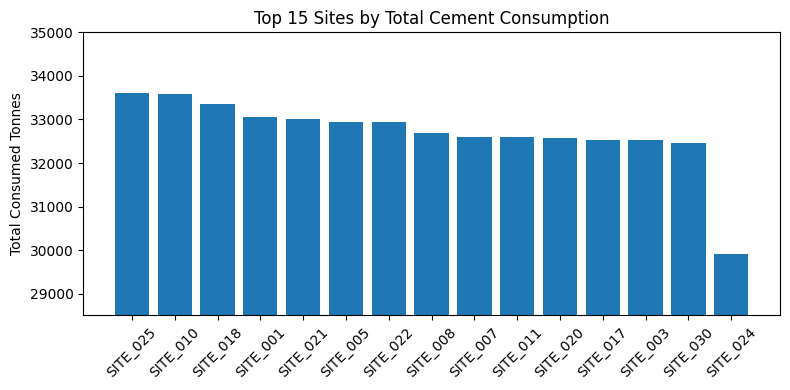

In [53]:
# display in bar chart
plt.figure(figsize=(8, 4))
plt.bar(top_sites['site_id'], top_sites['total_consumed_tonnes'])
plt.title('Top 15 Sites by Total Cement Consumption')
plt.xticks(rotation=45)
plt.ylim(28500, 35000)
plt.ylabel('Total Consumed Tonnes')
plt.tight_layout()
plt.show()

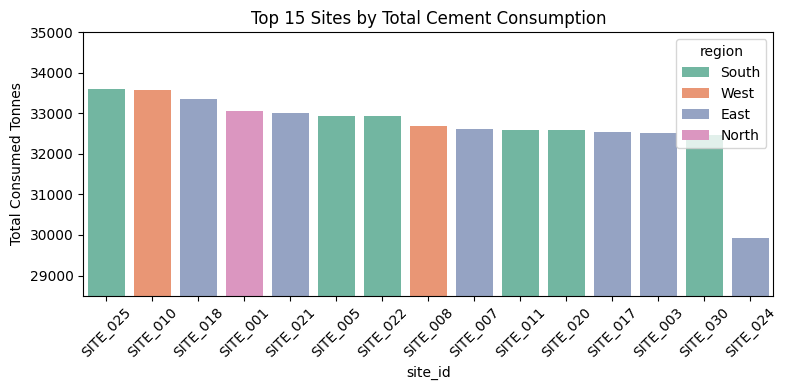

In [55]:
# display in bar chart
plt.figure(figsize=(8, 4))
sns.barplot(
  x='site_id', 
  y='total_consumed_tonnes', 
  data=top_sites, 
  hue='region', 
  dodge=False, 
  palette='Set2'
)
plt.title('Top 15 Sites by Total Cement Consumption')
plt.xticks(rotation=45)
plt.ylim(28500, 35000)
plt.ylabel('Total Consumed Tonnes')
plt.tight_layout()
plt.show()

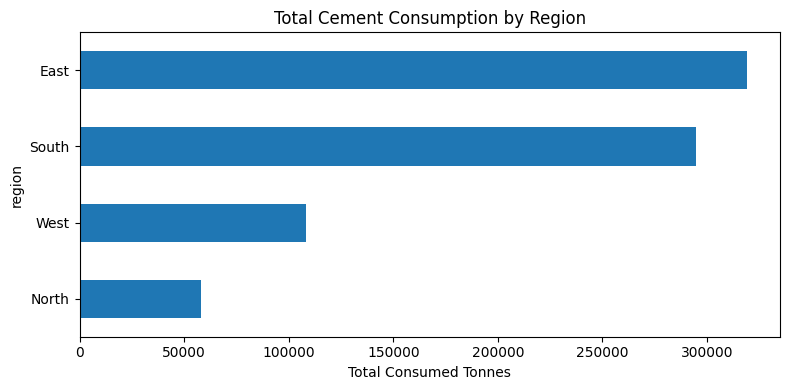

In [56]:
# site with the highest total cement consumption
region_consumption = df.groupby('region')['consumed_tonnes'].sum().sort_values()
region_consumption.plot(kind='barh', figsize=(8, 4), title='Total Cement Consumption by Region')
plt.xlabel('Total Consumed Tonnes')
plt.tight_layout()
plt.show()